<a href="https://colab.research.google.com/github/James21210/Learning-ML/blob/main/%EC%B0%A8%EB%AC%B4%EA%B4%80_%EA%B8%B0%EA%B3%84%ED%95%99%EC%8A%B5_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#기계학습 프로젝트 중간고사
**학번: 2022112004 |
이름: 차무관 |
일시: 2026.04.22**

## 데이터셋 분석

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('mid_train.csv')
TEST_data = pd.read_csv('mid_test.csv')

In [2]:
data.shape

(960, 21)

In [3]:
TEST_data.shape

(240, 21)

### 특징 파악 및 정답 레이블 확인

In [4]:
data.info()
# 0: 학번 (object)
# 1: 나이
# 2: 성별 (object)
# 3: 전공 (object)
# 4: 몇기 (object)
# 5: 거주 (object)
# 6: 알바유무 (object)
# 7: 장학금 (object)
# 8: 기기 유무 (object)
# 9: 한주당 공부시간
# 10: 출석점수
# 11: 숙제 점수
# 12: 중간고사 점수
# 13: 프로젝트 점수
# 14: 수면시간
# 15: 인터넷 사용시간
# 16: 통근 시간
# 17: 가족 소득
# 18: 클럽 활동 횟수
# -> 성적 예측 모델 (회귀)
# -> 패논패 모델 (분류)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              960 non-null    object 
 1   age                     960 non-null    float64
 2   gender                  960 non-null    object 
 3   major                   940 non-null    object 
 4   year                    939 non-null    object 
 5   residence               936 non-null    object 
 6   part_time_job           939 non-null    object 
 7   scholarship             388 non-null    object 
 8   device_type             950 non-null    object 
 9   study_hours_per_week    891 non-null    float64
 10  attendance_rate         901 non-null    float64
 11  assignment_score        907 non-null    float64
 12  midterm_score           912 non-null    float64
 13  project_score           921 non-null    float64
 14  sleep_hours             893 non-null    fl

In [5]:
data

,student_id,age,gender,major,year,residence,part_time_job,scholarship,device_type,study_hours_per_week,...,assignment_score,midterm_score,project_score,sleep_hours,internet_usage_hours,commute_time_min,family_income_index,club_activities_count,final_score_regression,academic_success_class
0,ST100226,20.2,Female,Computer Science,NaN,Dorm,No,Partial,Tablet,3.9,...,62.3,81.0,60.2,6.9,1.7,5.5,32.3,1.0,55.1,Pass
1,ST100331,20.1,Male,Business,2nd,Dorm,No,NaN,Laptop,0.7,...,58.9,69.2,59.7,8.1,3.0,4.8,26.0,1.0,43.3,Pass
2,ST100412,22.6,Female,Biology,3rd,Home,Yes,NaN,Laptop,6.9,...,37.9,40.2,50.1,8.0,5.2,25.5,25.0,2.0,34.5,Pass
3,ST100960,21.8,Male,Business,1st,Dorm,No,Partial,Laptop,9.8,...,51.9,61.3,38.6,7.4,1.4,9.5,17.7,2.0,50.3,Pass
4,ST100699,26.7,Female,Computer Science,3rd,Home,Yes,Partial,Desktop,7.3,...,82.5,57.8,58.8,6.8,7.1,51.2,28.5,0.0,46.0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,ST101086,18.0,Male,Business,NaN,Home,No,Partial,Desktop,12.5,...,52.2,NaN,61.7,6.6,NaN,27.2,39.9,2.0,53.1,Pass
956,ST100022,21.4,Male,Biology,3rd,Home,Yes,Partial,Laptop,19.9,...,65.8,89.9,92.9,5.0,1.8,63.0,34.5,0.0,61.4,Pass
957,ST100380,23.8,Male,Biology,1st,Off-campus,No,NaN,Laptop,14.9,...,63.2,59.5,92.5,7.6,4.2,29.9,38.2,3.0,57.6,Pass
958,ST100987,22.6,Male,Computer Science,2nd,Home,No,NaN,Laptop,15.3,...,69.2,72.2,65.4,7.1,5.6,37.4,44.2,1.0,50.1,Pass


In [6]:
data.nunique()

,0
student_id,960
age,102
gender,2
major,5
year,4
residence,3
part_time_job,2
scholarship,2
device_type,3
study_hours_per_week,201


### mid_test.csv와 mid_test.csv의 정답 비율이 골고루 분포되어 있는지 확인할 예정

In [7]:
data['academic_success_class'].value_counts()

,count
academic_success_class,
Pass,849
Fail,111


In [8]:
TEST_data['academic_success_class'].value_counts()

,count
academic_success_class,
Pass,212
Fail,28


In [9]:
data['final_score_regression'].describe()

,final_score_regression
count,960.000000
mean,48.429063
std,9.008834
min,24.500000
25%,42.075000
50%,48.600000
75%,54.400000
max,74.900000


In [10]:
TEST_data['final_score_regression'].describe()

,final_score_regression
count,240.000000
mean,47.943750
std,8.764194
min,26.100000
25%,42.175000
50%,47.650000
75%,54.625000
max,73.000000


In [11]:
# 비율은 비슷한 것 같고, 데이터량이 그렇게 많진 않으니 train_test_split를 사용하지 않을 예정
# test데이터와 train 데이터가 이미 분리 되어있기 때문!

## 전처리


In [12]:
# 학번 drop
data.drop('student_id', axis=1, inplace= True)
TEST_data.drop('student_id', axis=1, inplace= True)

### 범주형 데이터 수치형으로 변환

In [13]:
#2   gender                  960 non-null    object
#3   major                   940 non-null    object
#4   year                    939 non-null    object
#5   residence               936 non-null    object
#6   part_time_job           939 non-null    object
#7   scholarship             388 non-null    object
#8   device_type             950 non-null    object

In [14]:
#원핫인코딩 사용
data = pd.get_dummies(data, columns = ['gender','major','year','residence','part_time_job','scholarship','device_type'], drop_first=True)
TEST_data = pd.get_dummies(TEST_data, columns = ['gender','major','year','residence','part_time_job','scholarship','device_type'], drop_first=True)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     960 non-null    float64
 1   study_hours_per_week    891 non-null    float64
 2   attendance_rate         901 non-null    float64
 3   assignment_score        907 non-null    float64
 4   midterm_score           912 non-null    float64
 5   project_score           921 non-null    float64
 6   sleep_hours             893 non-null    float64
 7   internet_usage_hours    932 non-null    float64
 8   commute_time_min        933 non-null    float64
 9   family_income_index     896 non-null    float64
 10  club_activities_count   935 non-null    float64
 11  final_score_regression  960 non-null    float64
 12  academic_success_class  960 non-null    object 
 13  gender_Male             960 non-null    bool   
 14  major_Business          960 non-null    bo

### 결측치 처리

In [16]:
# 결측치 확인
data.isna().sum()

,0
age,0
study_hours_per_week,69
attendance_rate,59
assignment_score,53
midterm_score,48
project_score,39
sleep_hours,67
internet_usage_hours,28
commute_time_min,27
family_income_index,64


In [17]:
# 데이터 분포 확인
data.describe()

,age,study_hours_per_week,attendance_rate,assignment_score,midterm_score,project_score,sleep_hours,internet_usage_hours,commute_time_min,family_income_index,club_activities_count,final_score_regression
count,960.000000,891.000000,901.000000,907.000000,912.000000,921.000000,893.000000,932.000000,933.000000,896.000000,935.000000,960.000000
mean,21.589688,9.862065,77.811654,62.348622,65.330154,60.635396,6.508399,5.069099,27.551340,40.291071,1.899465,48.429063
std,2.490291,5.021278,10.845357,15.153232,16.734469,14.039768,0.919365,1.712439,18.318721,18.386752,1.402258,9.008834
min,18.000000,0.000000,41.900000,20.000000,15.000000,10.000000,3.600000,0.500000,0.000000,15.000000,0.000000,24.500000
25%,19.500000,6.200000,71.100000,51.800000,54.275000,51.200000,5.900000,3.900000,13.000000,27.200000,1.000000,42.075000
50%,21.300000,9.800000,77.600000,62.600000,65.450000,61.000000,6.500000,5.000000,23.700000,36.950000,2.000000,48.600000
75%,23.300000,13.400000,85.700000,73.100000,76.550000,70.100000,7.100000,6.200000,40.100000,49.100000,3.000000,54.400000
max,29.800000,27.200000,100.000000,100.000000,100.000000,100.000000,9.300000,10.000000,98.300000,120.000000,7.000000,74.900000


In [18]:
# '한주 공부 시간' 결측치 행 예시로 확인
data[data['study_hours_per_week'].isna()]

,age,study_hours_per_week,attendance_rate,assignment_score,midterm_score,project_score,sleep_hours,internet_usage_hours,commute_time_min,family_income_index,...,major_Mechanical,year_2nd,year_3rd,year_4th,residence_Home,residence_Off-campus,part_time_job_Yes,scholarship_Partial,device_type_Laptop,device_type_Tablet
25,24.2,NaN,NaN,69.0,69.6,63.0,5.8,4.1,34.2,27.7,...,False,False,False,False,False,True,True,False,False,False
48,19.7,NaN,67.4,70.1,57.6,69.3,6.1,6.2,12.4,20.6,...,True,False,False,False,False,False,True,True,True,False
50,18.8,NaN,NaN,43.1,54.4,50.3,5.3,2.9,57.7,44.4,...,False,False,True,False,True,False,True,False,True,False
60,22.9,NaN,83.5,56.6,68.5,67.8,6.8,NaN,10.9,NaN,...,False,False,True,False,False,False,False,False,False,False
65,19.4,NaN,NaN,38.8,34.3,47.8,NaN,9.5,40.8,65.7,...,False,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,22.3,NaN,99.9,65.8,82.6,56.6,6.5,5.6,10.6,44.2,...,False,True,False,False,False,False,True,False,True,False
902,23.3,NaN,79.1,49.7,32.7,45.5,5.9,6.1,37.3,65.3,...,False,False,False,True,True,False,False,False,True,False
912,23.5,NaN,78.4,59.1,45.8,47.0,5.5,5.2,29.1,NaN,...,False,False,False,True,True,False,True,False,True,False
927,21.7,NaN,53.7,30.8,35.0,54.0,6.4,7.0,33.8,17.9,...,False,False,False,False,True,False,True,False,True,False


In [19]:
# 평균값
data['study_hours_per_week'].mean()

np.float64(9.86206509539843)

In [20]:
# 중앙값
data['study_hours_per_week'].median()

9.8

In [21]:
data.isna().sum()

,0
age,0
study_hours_per_week,69
attendance_rate,59
assignment_score,53
midterm_score,48
project_score,39
sleep_hours,67
internet_usage_hours,28
commute_time_min,27
family_income_index,64


In [22]:
# study_hours_per_week	69
# attendance_rate	59
# assignment_score	53
# midterm_score	48
# project_score	39
# sleep_hours	67
# internet_usage_hours	28
# commute_time_min	27
# family_income_index	64
# club_activities_count	25

In [23]:
# 수치형 결측치 중앙 값으로 대체
data['study_hours_per_week'].fillna(data['study_hours_per_week'].mean(), inplace=True)
TEST_data['study_hours_per_week'].fillna(TEST_data['study_hours_per_week'].mean(), inplace=True)

data['attendance_rate'].fillna(data['attendance_rate'].mean(), inplace=True)
TEST_data['attendance_rate'].fillna(TEST_data['attendance_rate'].mean(), inplace=True)

data['assignment_score'].fillna(data['assignment_score'].mean(), inplace=True)
TEST_data['assignment_score'].fillna(TEST_data['assignment_score'].mean(), inplace=True)

data['midterm_score'].fillna(data['midterm_score'].mean(), inplace=True)
TEST_data['midterm_score'].fillna(TEST_data['midterm_score'].mean(), inplace=True)

data['project_score'].fillna(data['project_score'].mean(), inplace=True)
TEST_data['project_score'].fillna(TEST_data['project_score'].mean(), inplace=True)

data['sleep_hours'].fillna(data['sleep_hours'].mean(), inplace=True)
TEST_data['sleep_hours'].fillna(TEST_data['sleep_hours'].mean(), inplace=True)

data['internet_usage_hours'].fillna(data['internet_usage_hours'].mean(), inplace=True)
TEST_data['internet_usage_hours'].fillna(TEST_data['internet_usage_hours'].mean(), inplace=True)

data['commute_time_min'].fillna(data['commute_time_min'].mean(), inplace=True)
TEST_data['commute_time_min'].fillna(TEST_data['commute_time_min'].mean(), inplace=True)

data['family_income_index'].fillna(data['family_income_index'].mean(), inplace=True)
TEST_data['family_income_index'].fillna(TEST_data['family_income_index'].mean(), inplace=True)

data['club_activities_count'].fillna(data['club_activities_count'].mean(), inplace=True)
TEST_data['club_activities_count'].fillna(TEST_data['club_activities_count'].mean(), inplace=True)


/tmp/ipykernel_45711/3596406534.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['study_hours_per_week'].fillna(data['study_hours_per_week'].mean(), inplace=True)
/tmp/ipykernel_45711/3596406534.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df

In [24]:
data.isna().sum()

,0
age,0
study_hours_per_week,0
attendance_rate,0
assignment_score,0
midterm_score,0
project_score,0
sleep_hours,0
internet_usage_hours,0
commute_time_min,0
family_income_index,0


In [25]:
TEST_data.isna().sum()

,0
age,0
study_hours_per_week,0
attendance_rate,0
assignment_score,0
midterm_score,0
project_score,0
sleep_hours,0
internet_usage_hours,0
commute_time_min,0
family_income_index,0


### 정답 레이블 제거 및 정답 레이블 생성

In [26]:
X_data = data.drop(['academic_success_class','final_score_regression'], axis=1)
y_classi_data = data['academic_success_class']
y_reg_data = data['final_score_regression']

X_TEST_data = TEST_data.drop(['academic_success_class','final_score_regression'], axis=1)
y_TEST_classi_data = TEST_data['academic_success_class']
y_TEST_reg_data = TEST_data['final_score_regression']

### 특징 분석

In [ ]:
#일단 스킵

## 데이터 학습

In [62]:
# 랜덤 포레스트 회귀 모델 사용
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=100)
model.fit(X_data, y_reg_data)
train_pred = model.predict(X_data)
test_pred = model.predict(X_TEST_data)

In [29]:
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score

#훈련용 평가
mse = mean_squared_error(y_reg_data, train_pred)
print("mse: ", mse)

#테스트용 평가
mse = mean_squared_error(y_TEST_reg_data, test_pred)
print("mse: ", mse)

mse:  3.540700320833331
mse:  27.08757591250002


,age,study_hours_per_week,attendance_rate,assignment_score,midterm_score,project_score,sleep_hours,internet_usage_hours,commute_time_min,family_income_index,...,major_Mechanical,year_2nd,year_3rd,year_4th,residence_Home,residence_Off-campus,part_time_job_Yes,scholarship_Partial,device_type_Laptop,device_type_Tablet
0,20.2,3.9,74.200000,62.3,81.000000,60.2,6.9,1.700000,5.5,32.3,...,False,False,False,False,False,False,False,True,False,True
1,20.1,0.7,63.100000,58.9,69.200000,59.7,8.1,3.000000,4.8,26.0,...,False,True,False,False,False,False,False,False,True,False
2,22.6,6.9,54.700000,37.9,40.200000,50.1,8.0,5.200000,25.5,25.0,...,False,False,True,False,True,False,True,False,True,False
3,21.8,9.8,79.700000,51.9,61.300000,38.6,7.4,1.400000,9.5,17.7,...,False,False,False,False,False,False,False,True,True,False
4,26.7,7.3,69.200000,82.5,57.800000,58.8,6.8,7.100000,51.2,28.5,...,False,False,True,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,18.0,12.5,70.700000,52.2,65.330154,61.7,6.6,5.069099,27.2,39.9,...,False,False,False,False,True,False,False,True,False,False
956,21.4,19.9,82.800000,65.8,89.900000,92.9,5.0,1.800000,63.0,34.5,...,False,False,True,False,True,False,True,True,True,False
957,23.8,14.9,77.811654,63.2,59.500000,92.5,7.6,4.200000,29.9,38.2,...,False,False,False,False,False,True,False,False,True,False
958,22.6,15.3,79.100000,69.2,72.200000,65.4,7.1,5.600000,37.4,44.2,...,False,True,False,False,True,False,False,False,True,False


In [72]:
# 랜덤 포레스트 클래시파이어 사용
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=100)
model.fit(X_data, y_classi_data)
train_pred1 = model.predict(X_data)
test_pred1 = model.predict(X_TEST_data)

In [64]:
train_pred1 = pd.DataFrame(train_pred1)

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_TEST_classi_data, test_pred1))

              precision    recall  f1-score   support

        Fail       0.72      0.46      0.57        28
        Pass       0.93      0.98      0.95       212

    accuracy                           0.92       240
   macro avg       0.83      0.72      0.76       240
weighted avg       0.91      0.92      0.91       240



### F1_score과 recall 높이기
적진 못했는데, class_weight='balanced'와 class_weight={'Pass':1,'Fail':10} 으로 해도 recall 과 f1-score이 떨어지는 모습을 보임. 오히려 모델이 감을 못잡아서 둘 다 떨어짐-> 모델 단순화 필요

#### 특징분석

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     960 non-null    float64
 1   study_hours_per_week    960 non-null    float64
 2   attendance_rate         960 non-null    float64
 3   assignment_score        960 non-null    float64
 4   midterm_score           960 non-null    float64
 5   project_score           960 non-null    float64
 6   sleep_hours             960 non-null    float64
 7   internet_usage_hours    960 non-null    float64
 8   commute_time_min        960 non-null    float64
 9   family_income_index     960 non-null    float64
 10  club_activities_count   960 non-null    float64
 11  final_score_regression  960 non-null    float64
 12  academic_success_class  960 non-null    object 
 13  gender_Male             960 non-null    bool   
 14  major_Business          960 non-null    bo

In [105]:
data['academic_success_class']

,academic_success_class
0,True
1,True
2,True
3,True
4,True
...,...
955,True
956,True
957,True
958,True


In [99]:
data['academic_success_class'] = data['academic_success_class'].astype(bool)

In [104]:
data[False==data['academic_success_class']]

,age,study_hours_per_week,attendance_rate,assignment_score,midterm_score,project_score,sleep_hours,internet_usage_hours,commute_time_min,family_income_index,...,major_Mechanical,year_2nd,year_3rd,year_4th,residence_Home,residence_Off-campus,part_time_job_Yes,scholarship_Partial,device_type_Laptop,device_type_Tablet


In [103]:
data['year_2nd']

,year_2nd
0,False
1,True
2,False
3,False
4,False
...,...
955,False
956,False
957,False
958,True


<Axes: >

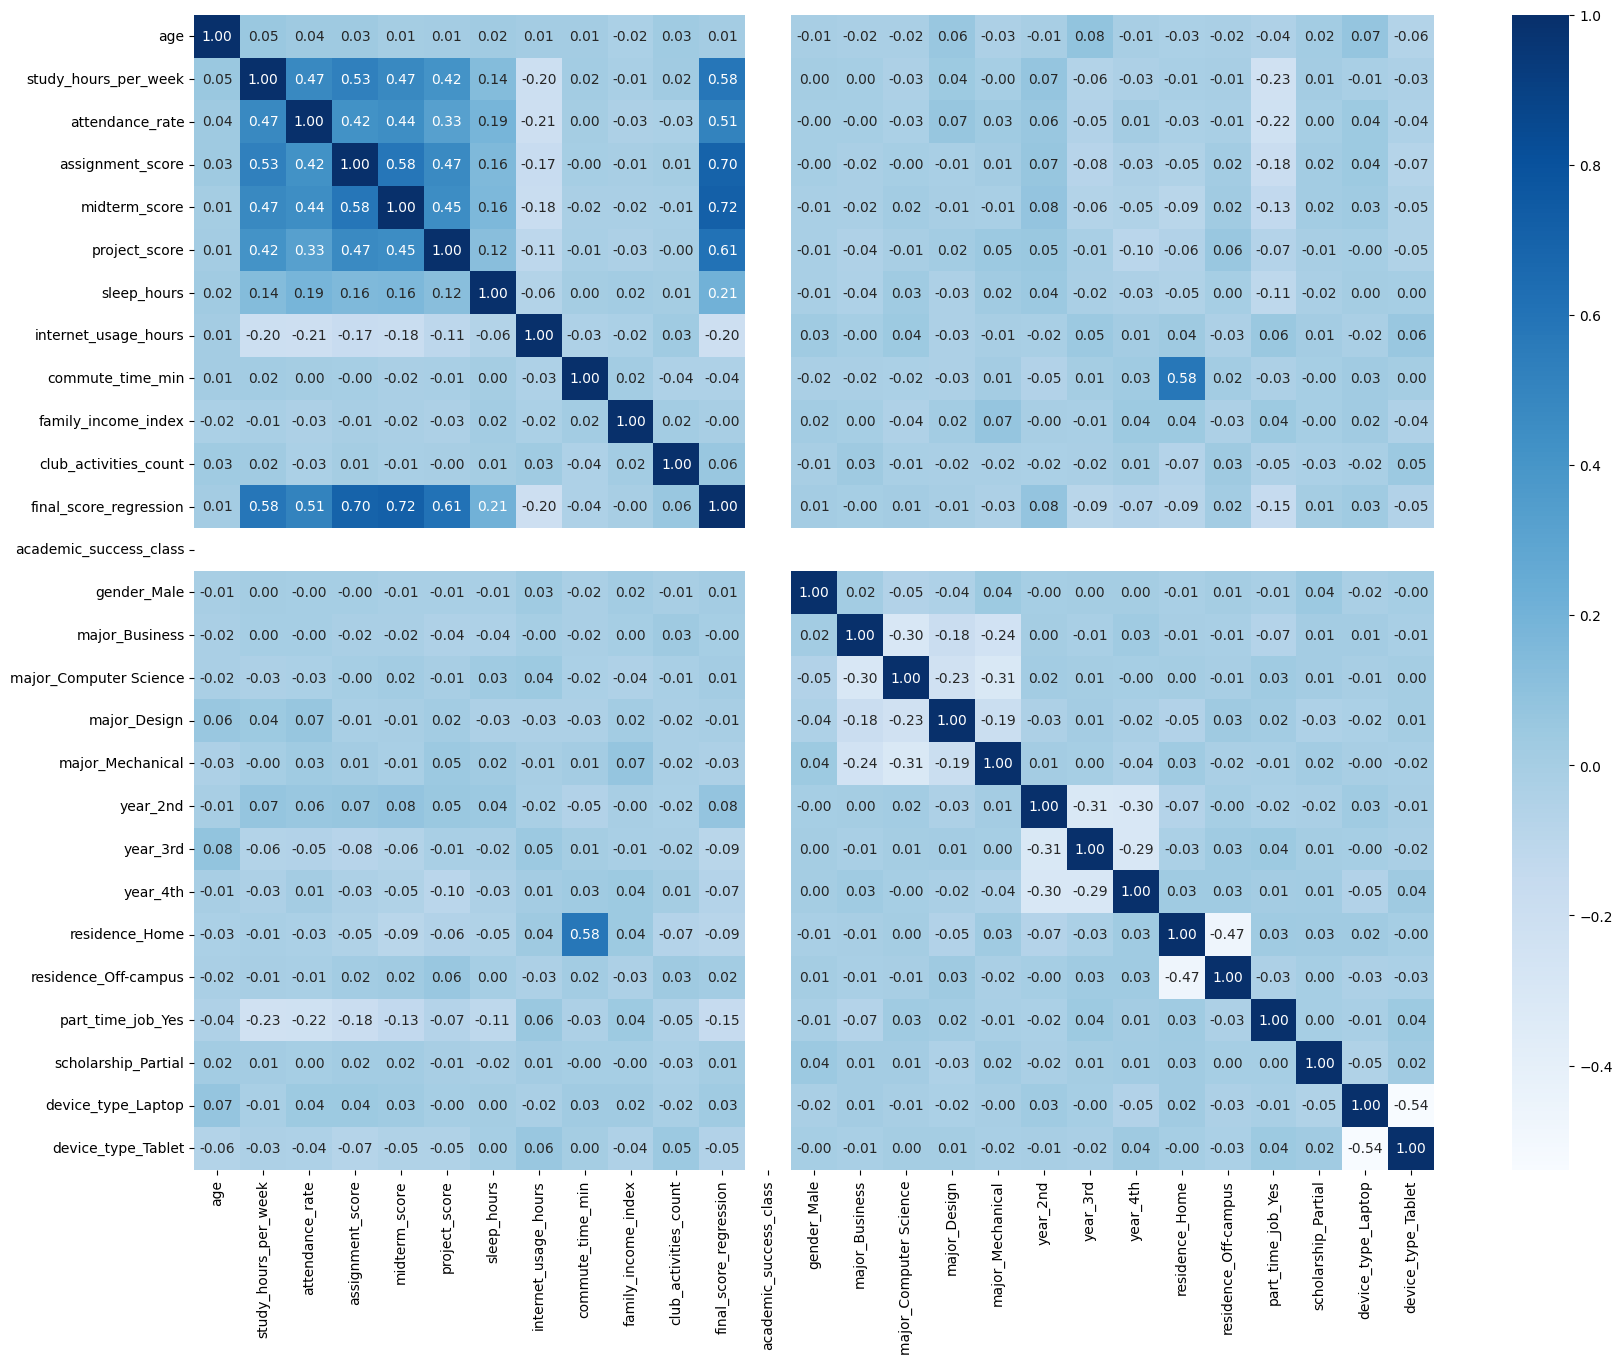

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))

data1 = data.select_dtypes(include=['bool','number']).astype(int).corr()
sns.heatmap(data1, annot=True, fmt='.2f', cmap='Blues')

In [90]:
# 'final_score_regression'과 상관관계 절대값이 0.1보다 작은 테이블 drop
target_corr = data1['final_score_regression'].abs()

low_corr_features = target_corr[target_corr < 0.1].index.tolist()

data_filtered = data.drop(columns=low_corr_features)

In [93]:
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   study_hours_per_week    960 non-null    float64
 1   attendance_rate         960 non-null    float64
 2   assignment_score        960 non-null    float64
 3   midterm_score           960 non-null    float64
 4   project_score           960 non-null    float64
 5   sleep_hours             960 non-null    float64
 6   internet_usage_hours    960 non-null    float64
 7   final_score_regression  960 non-null    float64
 8   academic_success_class  960 non-null    object 
 9   part_time_job_Yes       960 non-null    bool   
dtypes: bool(1), float64(8), object(1)
memory usage: 68.6+ KB


#### 랜덤포레스트 클래시파이어 재학습

In [ ]:
X_data = data.drop(['academic_success_class','final_score_regression'], axis=1)
y_classi_data = data['academic_success_class']
y_reg_data = data['final_score_regression']

X_TEST_data = TEST_data.drop(['academic_success_class','final_score_regression'], axis=1)
y_TEST_classi_data = TEST_data['academic_success_class']
y_TEST_reg_data = TEST_data['final_score_regression']